In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)


In [5]:
# Color palette
STAY_COLOR  = '#2ECC71'
LEAVE_COLOR = '#E74C3C'
BG_COLOR    = '#F8F9FA'
GRID_COLOR  = '#DEE2E6'

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [7]:
df = pd.read_csv('HR_comma_sep.csv')

print(f"📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n🎯 Target Distribution:")
print(df['left'].value_counts().rename({0: 'Stayed (0)', 1: 'Left (1)'}))
df.head(10)

📊 Dataset Shape: 14999 rows × 10 columns

🎯 Target Distribution:
Stayed (0)    11428
Left (1)       3571
Name: left, dtype: int64


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [8]:
print("📋 Data Types & Missing Values:")
info = pd.DataFrame({'Missing': df.isnull().sum(), 'DType': df.dtypes})
print(info)
print("\n📈 Statistical Summary:")
df.describe().round(3)

📋 Data Types & Missing Values:
                       Missing    DType
satisfaction_level           0  float64
last_evaluation              0  float64
number_project               0    int64
average_montly_hours         0    int64
time_spend_company           0    int64
Work_accident                0    int64
left                         0    int64
promotion_last_5years        0    int64
Department                   0   object
salary                       0   object

📈 Statistical Summary:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000
mean,0.613,0.716,3.803,201.050,3.498,0.145,0.238,0.021
std,0.249,0.171,1.233,49.943,1.460,0.352,0.426,0.144
min,0.090,0.360,2.000,96.000,2.000,0.000,0.000,0.000
25%,0.440,0.560,3.000,156.000,3.000,0.000,0.000,0.000
50%,0.640,0.720,4.000,200.000,3.000,0.000,0.000,0.000
75%,0.820,0.870,5.000,245.000,4.000,0.000,0.000,0.000
max,1.000,1.000,7.000,310.000,10.000,1.000,1.000,1.000


In [9]:
print("📋 Data Types & Missing Values:")
info = pd.DataFrame({'Missing': df.isnull().sum(), 'DType': df.dtypes})
print(info)
print("\n📈 Statistical Summary:")
df.describe().round(3)

📋 Data Types & Missing Values:
                       Missing    DType
satisfaction_level           0  float64
last_evaluation              0  float64
number_project               0    int64
average_montly_hours         0    int64
time_spend_company           0    int64
Work_accident                0    int64
left                         0    int64
promotion_last_5years        0    int64
Department                   0   object
salary                       0   object

📈 Statistical Summary:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000
mean,0.613,0.716,3.803,201.050,3.498,0.145,0.238,0.021
std,0.249,0.171,1.233,49.943,1.460,0.352,0.426,0.144
min,0.090,0.360,2.000,96.000,2.000,0.000,0.000,0.000
25%,0.440,0.560,3.000,156.000,3.000,0.000,0.000,0.000
50%,0.640,0.720,4.000,200.000,3.000,0.000,0.000,0.000
75%,0.820,0.870,5.000,245.000,4.000,0.000,0.000,0.000
max,1.000,1.000,7.000,310.000,10.000,1.000,1.000,1.000


In [10]:
print("📋 Data Types & Missing Values:")
info = pd.DataFrame({'Missing': df.isnull().sum(), 'DType': df.dtypes})
print(info)
print("\n📈 Statistical Summary:")
df.describe().round(3)

📋 Data Types & Missing Values:
                       Missing    DType
satisfaction_level           0  float64
last_evaluation              0  float64
number_project               0    int64
average_montly_hours         0    int64
time_spend_company           0    int64
Work_accident                0    int64
left                         0    int64
promotion_last_5years        0    int64
Department                   0   object
salary                       0   object

📈 Statistical Summary:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000
mean,0.613,0.716,3.803,201.050,3.498,0.145,0.238,0.021
std,0.249,0.171,1.233,49.943,1.460,0.352,0.426,0.144
min,0.090,0.360,2.000,96.000,2.000,0.000,0.000,0.000
25%,0.440,0.560,3.000,156.000,3.000,0.000,0.000,0.000
50%,0.640,0.720,4.000,200.000,3.000,0.000,0.000,0.000
75%,0.820,0.870,5.000,245.000,4.000,0.000,0.000,0.000
max,1.000,1.000,7.000,310.000,10.000,1.000,1.000,1.000


In [11]:
salary_order = ['low', 'medium', 'high']
salary_data = df.groupby(['salary', 'left']).size().unstack(fill_value=0)
salary_data = salary_data.reindex(salary_order)
salary_data.columns = ['Stayed', 'Left']
salary_data['Total']  = salary_data.sum(axis=1)
salary_data['Leave%'] = (salary_data['Left'] / salary_data['Total'] * 100).round(1)

print("📊 Salary vs Retention Summary:")
print(salary_data)

📊 Salary vs Retention Summary:
        Stayed  Left  Total  Leave%
salary                             
low       5144  2172   7316    29.7
medium    5129  1317   6446    20.4
high      1155    82   1237     6.6


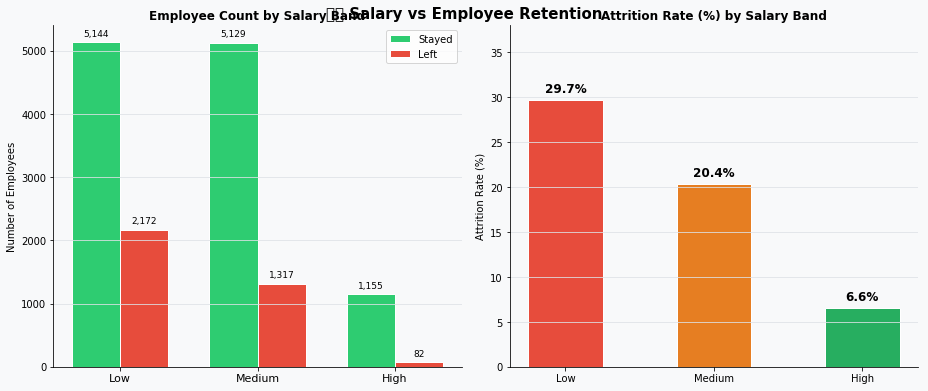

In [12]:
x = np.arange(3)
w = 0.35
labels = [s.capitalize() for s in salary_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('💰 Salary vs Employee Retention', fontsize=15, fontweight='bold')

ax = axes[0]; ax.set_facecolor(BG_COLOR)
b1 = ax.bar(x - w/2, salary_data['Stayed'], w, label='Stayed', color=STAY_COLOR, edgecolor='white')
b2 = ax.bar(x + w/2, salary_data['Left'],   w, label='Left',   color=LEAVE_COLOR, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Employee Count by Salary Band', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Employees'); ax.grid(axis='y', color=GRID_COLOR)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax = axes[1]; ax.set_facecolor(BG_COLOR)
bars2 = ax.bar(labels, salary_data['Leave%'],
               color=[LEAVE_COLOR, '#E67E22', '#27AE60'], edgecolor='white', width=0.5)
ax.set_title('Attrition Rate (%) by Salary Band', fontsize=12, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)'); ax.grid(axis='y', color=GRID_COLOR); ax.set_ylim(0, 38)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, val in zip(bars2, salary_data['Leave%']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.savefig('2_salary_retention.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
dept_data = df.groupby(['Department', 'left']).size().unstack(fill_value=0)
dept_data.columns = ['Stayed', 'Left']
dept_data['Total']  = dept_data.sum(axis=1)
dept_data['Leave%'] = (dept_data['Left'] / dept_data['Total'] * 100).round(1)
dept_data = dept_data.sort_values('Leave%', ascending=False)

print("📊 Department vs Retention:")
print(dept_data)

📊 Department vs Retention:
             Stayed  Left  Total  Leave%
Department                              
hr              524   215    739    29.1
accounting      563   204    767    26.6
technical      2023   697   2720    25.6
support        1674   555   2229    24.9
sales          3126  1014   4140    24.5
marketing       655   203    858    23.7
IT              954   273   1227    22.2
product_mng     704   198    902    22.0
RandD           666   121    787    15.4
management      539    91    630    14.4


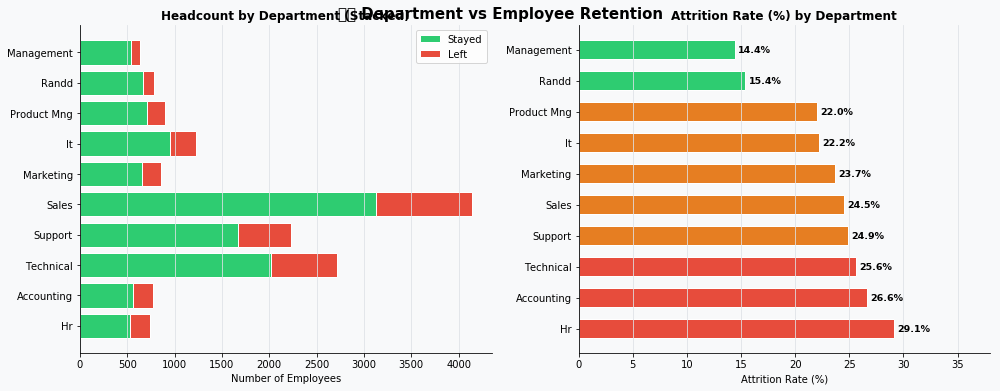

In [14]:
dept_labels = [d.replace('_', ' ').title() for d in dept_data.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('🏢 Department vs Employee Retention', fontsize=15, fontweight='bold')

ax = axes[0]; ax.set_facecolor(BG_COLOR)
ax.barh(dept_labels, dept_data['Stayed'], color=STAY_COLOR, label='Stayed', edgecolor='white')
ax.barh(dept_labels, dept_data['Left'], left=dept_data['Stayed'],
        color=LEAVE_COLOR, label='Left', edgecolor='white')
ax.set_title('Headcount by Department (Stacked)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Employees'); ax.legend(fontsize=10)
ax.grid(axis='x', color=GRID_COLOR)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]; ax.set_facecolor(BG_COLOR)
bar_colors3 = [LEAVE_COLOR if v > 25 else '#E67E22' if v > 20 else STAY_COLOR
               for v in dept_data['Leave%']]
bars3 = ax.barh(dept_labels, dept_data['Leave%'], color=bar_colors3, edgecolor='white', height=0.6)
ax.set_title('Attrition Rate (%) by Department', fontsize=12, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)'); ax.grid(axis='x', color=GRID_COLOR); ax.set_xlim(0, 38)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, val in zip(bars3, dept_data['Leave%']):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout(); plt.savefig('3_department_retention.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df2 = df.copy()
le = LabelEncoder()
df2['salary_enc'] = le.fit_transform(df2['salary'])

features = [
    'satisfaction_level', 'time_spend_company', 'Work_accident',
    'average_montly_hours', 'salary_enc', 'promotion_last_5years',
    'number_project', 'last_evaluation'
]
feature_labels = [
    'Satisfaction Level', 'Time at Company', 'Work Accident',
    'Avg Monthly Hours', 'Salary', 'Promotion (5yr)',
    'Num Projects', 'Last Evaluation'
]

X = df2[features]
y = df2['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_s, y_train)

print("✅ Model trained!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Test samples     : {X_test.shape[0]}")

✅ Model trained!
   Training samples : 11999
   Test samples     : 3000


In [16]:
y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm  = confusion_matrix(y_test, y_pred)

print("=" * 45)
print(f"  ✅ Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ✅ AUC-ROC   : {auc:.4f}")
print("=" * 45)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

  ✅ Accuracy  : 0.7700  (77.00%)
  ✅ AUC-ROC   : 0.8101

📋 Classification Report:
              precision    recall  f1-score   support

      Stayed       0.80      0.93      0.86      2286
        Left       0.53      0.26      0.35       714

   micro avg       0.77      0.77      0.77      3000
   macro avg       0.67      0.60      0.61      3000
weighted avg       0.74      0.77      0.74      3000



In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('🤖 Logistic Regression – Model Performance', fontsize=15, fontweight='bold')

ax = axes[0]; ax.set_facecolor(BG_COLOR)
ax.imshow(cm, cmap='RdYlGn', aspect='auto')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nStayed', 'Predicted\nLeft'], fontsize=10)
ax.set_yticklabels(['Actual\nStayed', 'Actual\nLeft'], fontsize=10)
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=18, fontweight='bold', color='black')

ax = axes[1]; ax.set_facecolor(BG_COLOR)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, color=LEAVE_COLOR, lw=2.5, label=f'ROC Curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='#aaa', lw=1.2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color=LEAVE_COLOR)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(color=GRID_COLOR)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('4_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

ValueError: Invalid RGBA argument: '#aaa'

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x0000029D5FFB2510> (for post_execute):


ValueError: Invalid RGBA argument: '#aaa'

ValueError: Invalid RGBA argument: '#aaa'

<Figure size 936x396 with 2 Axes>

In [18]:
coefs = model.coef_[0]
sorted_idx = np.argsort(coefs)
bar_colors5 = [LEAVE_COLOR if coefs[i] > 0 else STAY_COLOR for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_COLOR); ax.set_facecolor(BG_COLOR)

bars5 = ax.barh([feature_labels[i] for i in sorted_idx], coefs[sorted_idx],
                color=bar_colors5, edgecolor='white', height=0.6)
ax.axvline(0, color='#555', lw=1.2)
ax.set_xlabel('Logistic Regression Coefficient (Standardised)', fontsize=11)
ax.set_title('Feature Importance – Logistic Regression Coefficients',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', color=GRID_COLOR)
for bar, i in zip(bars5, sorted_idx):
    val = coefs[i]
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9.5)

patch_l = mpatches.Patch(color=LEAVE_COLOR, label='Increases attrition risk')
patch_s = mpatches.Patch(color=STAY_COLOR,  label='Reduces attrition risk')
ax.legend(handles=[patch_l, patch_s], fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

ValueError: Invalid RGBA argument: '#555'

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x0000029D5FFB2510> (for post_execute):


ValueError: Invalid RGBA argument: '#555'

ValueError: Invalid RGBA argument: '#555'

<Figure size 720x396 with 1 Axes>